# 04 — Historical Transfer-Related Demand Analysis

This notebook analyzes the official January 2023 Taipei transfer-related YouBike trip dataset.

> Scope warning: the file contains trips associated with bus or MRT transfers, not the complete YouBike trip population. Timestamps are hourly buckets: minutes and seconds are suppressed to zero.

## 1. Load processed trips and reproducible reports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
processed_path = project_root / "data" / "processed" / "historical_transfers_2023_01.csv"
results_dir = project_root / "results"

if not processed_path.exists():
    raise FileNotFoundError(
        "Run python src/download_historical.py --month 2023-01 and "
        "python src/prepare_historical.py first."
    )

trips = pd.read_csv(
    processed_path,
    parse_dates=["borrow_time", "return_time", "borrow_date"],
)
quality = pd.read_csv(results_dir / "historical_quality_summary.csv")
daily = pd.read_csv(
    results_dir / "historical_daily_summary.csv", parse_dates=["borrow_date"]
)
hourly = pd.read_csv(results_dir / "historical_hourly_profile.csv")
top_stations = pd.read_csv(results_dir / "historical_top_stations.csv")

print(f"Transfer-related trips: {len(trips):,}")
print(f"Date range: {trips['borrow_date'].min().date()} to {trips['borrow_date'].max().date()}")
quality

Transfer-related trips: 593,616
Date range: 2023-01-01 to 2023-01-31


,metric,value
0,dataset_scope,transfer_related_trips_only
1,rows,593616
2,date_start,2023-01-01
3,date_end,2023-01-31
4,timestamp_granularity,hour
5,raw_missing_cells,0
6,exact_duplicate_extra_rows_retained,1611
7,unique_historical_station_names,1784
8,unique_names_matching_current,1208
9,borrow_rows_matching_current_percent,99.08


## 2. Compare weekday and weekend hourly profiles

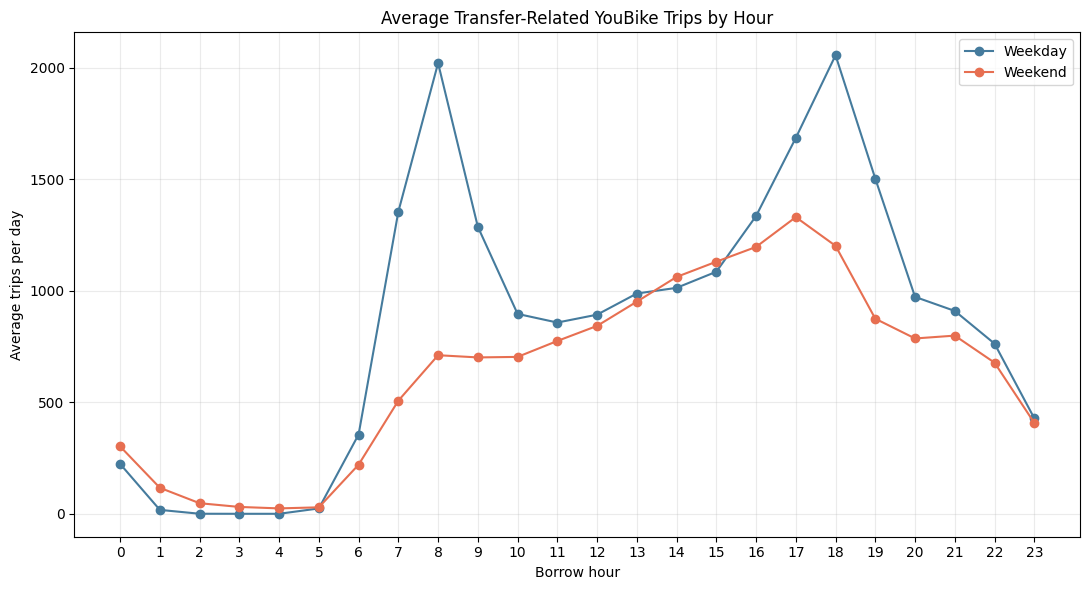

In [2]:
fig, ax = plt.subplots(figsize=(11, 6))
for is_weekend, label, color in [
    (False, "Weekday", "#457B9D"),
    (True, "Weekend", "#E76F51"),
]:
    profile = hourly[hourly["is_weekend"].eq(is_weekend)]
    ax.plot(
        profile["borrow_hour"],
        profile["average_trips_per_day"],
        marker="o",
        label=label,
        color=color,
    )
ax.set_title("Average Transfer-Related YouBike Trips by Hour")
ax.set_xlabel("Borrow hour")
ax.set_ylabel("Average trips per day")
ax.set_xticks(range(24))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Inspect daily volume

In [3]:
daily_type_summary = (
    daily.groupby("is_weekend")["trip_count"]
    .agg(["count", "mean", "median", "min", "max"])
    .rename(index={False: "Weekday", True: "Weekend"})
)
daily_type_summary.round(1)

,count,mean,median,min,max
is_weekend,,,,,
Weekday,22,20670.8,24151.5,7187,28522
Weekend,9,15428.8,15613.0,6331,24377


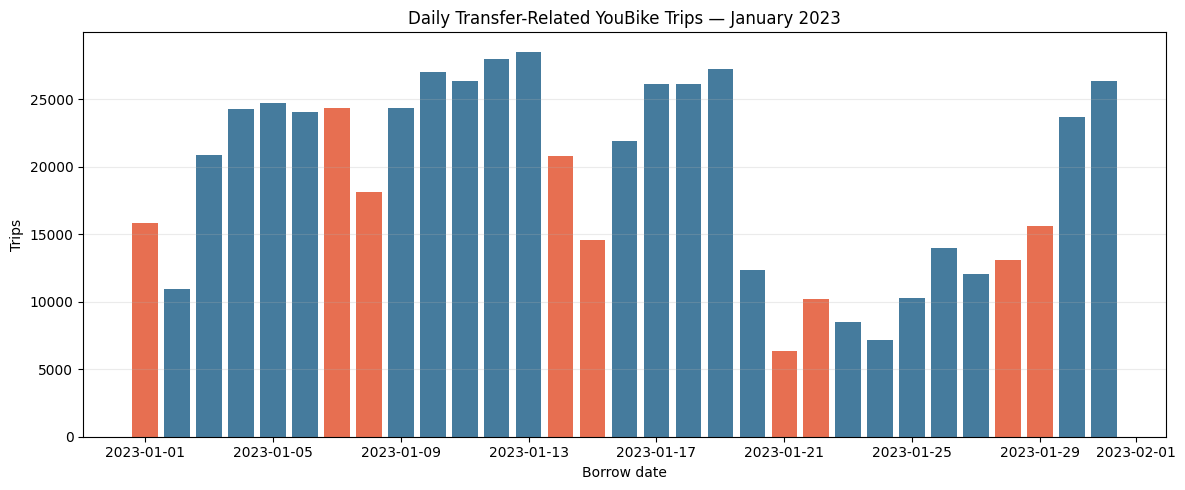

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = daily["is_weekend"].map({False: "#457B9D", True: "#E76F51"})
ax.bar(daily["borrow_date"], daily["trip_count"], color=colors)
ax.set_title("Daily Transfer-Related YouBike Trips — January 2023")
ax.set_xlabel("Borrow date")
ax.set_ylabel("Trips")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Review high-activity stations

In [5]:
top_borrow = top_stations.nlargest(10, "borrow_count")[
    ["station_name", "borrow_count", "current_station_match"]
]
top_return = top_stations.nlargest(10, "return_count")[
    ["station_name", "return_count", "current_station_match"]
]

print("Top borrowing stations")
display(top_borrow)
print("Top returning stations")
display(top_return)

Top borrowing stations


,station_name,borrow_count,current_station_match
0,捷運芝山站(2號出口)_1,11319,True
2,捷運劍潭站(2號出口),10896,True
1,捷運公館站(3號出口),10456,True
3,捷運中山國中站,9171,True
4,捷運科技大樓站,8945,True
5,捷運芝山站(1號出口),8535,True
7,捷運龍山寺站(1號出口),7814,True
6,捷運行天宮站(3號出口),7628,True
9,捷運劍南路站(2號出口),6994,True
10,捷運六張犁站,6584,True


Top returning stations


,station_name,return_count,current_station_match
38,臺北醫學大學,3885,True
46,百齡國小,3684,True
47,永樂市場,3168,True
54,臺北市立圖書館(總館),3082,True
56,臺灣師範大學(圖書館),2866,True
70,清江國小,2863,True
69,樂群二敬業四路口,2772,True
60,雨農國小,2700,True
67,蘭雅公園,2684,True
65,建國和平路口西北側,2632,True


## 5. Inspect trip-duration distribution

In [6]:
duration_percentiles = trips["duration_minutes"].quantile(
    [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]
).rename("duration_minutes")
duration_percentiles

0.00       0.016667
0.25       4.500000
0.50       7.250000
0.75      13.683333
0.90      27.016667
0.95      45.887500
0.99     121.216667
1.00    1105.350000
Name: duration_minutes, dtype: float64

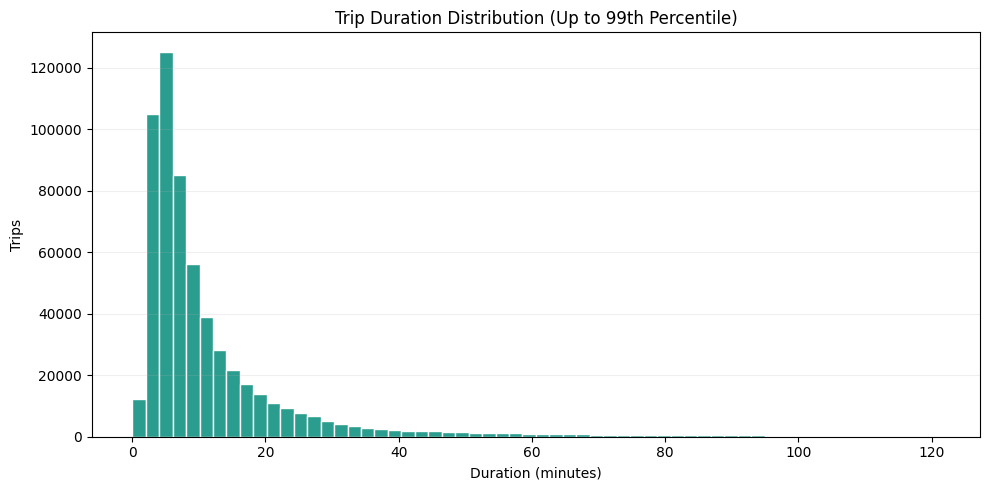

In [7]:
upper_limit = trips["duration_minutes"].quantile(0.99)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    trips.loc[trips["duration_minutes"].le(upper_limit), "duration_minutes"],
    bins=60,
    color="#2A9D8F",
    edgecolor="white",
)
ax.set_title("Trip Duration Distribution (Up to 99th Percentile)")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Trips")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## Initial findings and limits

- Weekdays show strong transfer-related peaks around 08:00 and 18:00.
- Weekend activity is more concentrated from the afternoon into early evening.
- Median recorded trip duration is about seven minutes; long trips are retained and flagged rather than silently removed.
- Historical station names are normalized and matched to the current snapshot without fuzzy matching.
- Identical rows are retained because the source provides no ride ID.
- These patterns describe transfer-related riders in January 2023 and must not be generalized to all YouBike users without validation.
- Hourly timestamps support hourly demand analysis, not direct 30-minute target construction.